# 日経平均株価 先物（CME日経先物 円建て）15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import pandas as pd
import yfinance as yf

In [3]:
symbol = "NIY=F"
ticker1 = yf.Ticker(symbol)
df = ticker1.history(period="1d", interval="15m")
df.index = df.index.tz_convert("Asia/Tokyo")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-22 13:00:00+09:00,72905.0,72905.0,72775.0,72775.0,84,0.0,0.0
2026-06-22 13:15:00+09:00,72780.0,72840.0,72650.0,72665.0,95,0.0,0.0
2026-06-22 13:30:00+09:00,72640.0,72700.0,72560.0,72615.0,150,0.0,0.0
2026-06-22 13:45:00+09:00,72625.0,72845.0,72600.0,72815.0,195,0.0,0.0
2026-06-22 14:00:00+09:00,72810.0,72865.0,72705.0,72800.0,119,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-23 04:45:00+09:00,73010.0,73165.0,73010.0,73140.0,530,0.0,0.0
2026-06-23 05:00:00+09:00,73140.0,73180.0,73110.0,73180.0,149,0.0,0.0
2026-06-23 05:15:00+09:00,73170.0,73175.0,73145.0,73145.0,11,0.0,0.0


In [4]:
# 先頭のタイムスタンプ（例：金曜のどこかの時刻）
dt0 = df.index[0]

# 金曜の日付だけを取り出す
fri = dt0.normalize()  # 00:00 に丸める

# 開始・終了
dt_start = fri + pd.Timedelta(hours=15, minutes=30)
dt_end = fri + pd.Timedelta(days=1, hours=6)
print(dt_start)
print(dt_end)

df = df[(dt_start <= df.index) & (df.index < dt_end)]
df

2026-06-22 15:30:00+09:00
2026-06-23 06:00:00+09:00


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-06-22 15:30:00+09:00,72690.0,72875.0,72545.0,72845.0,587,0.0,0.0
2026-06-22 15:45:00+09:00,72845.0,72915.0,72830.0,72885.0,291,0.0,0.0
2026-06-22 16:00:00+09:00,72880.0,73000.0,72870.0,72900.0,265,0.0,0.0
2026-06-22 16:15:00+09:00,72910.0,73010.0,72910.0,72950.0,266,0.0,0.0
2026-06-22 16:30:00+09:00,72945.0,72970.0,72805.0,72815.0,113,0.0,0.0
2026-06-22 16:45:00+09:00,72805.0,72865.0,72790.0,72830.0,104,0.0,0.0
2026-06-22 17:00:00+09:00,72835.0,72860.0,72625.0,72750.0,213,0.0,0.0
2026-06-22 17:15:00+09:00,72770.0,72845.0,72735.0,72780.0,76,0.0,0.0
2026-06-22 17:30:00+09:00,72765.0,72875.0,72730.0,72870.0,127,0.0,0.0


In [5]:
year_str = f"{dt_end.year:04d}"
month_str = f"{dt_end.month:02d}"
day_str = f"{dt_end.day:02d}"
output_path = os.path.join(year_str, month_str, day_str)
os.makedirs(output_path, exist_ok=True)
output_path

'2026/06/23'

## ローソク足チャート（小さいサイズ）

In [6]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

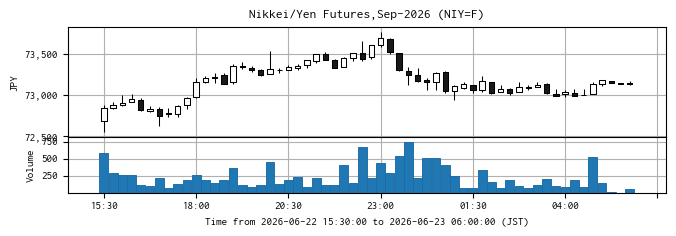

In [7]:
fig = plt.figure(figsize=(6.8, 2.4))
ax = dict()
n = 2
gs = fig.add_gridspec(
    n, 1, wspace=0.0, hspace=0.0, height_ratios=[2 if i == 0 else 1 for i in range(n)]
)
for i, axis in enumerate(gs.subplots(sharex="col")):
    ax[i] = axis
    ax[i].grid()

mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    volume=ax[1],
    ax=ax[0],
)
ax[0].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax[1].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax[1].set_xlabel(
    f"Time from {dt_start.replace(tzinfo=None)} "
    f"to {dt_end.replace(tzinfo=None)} (JST)"
)
ax[0].set_ylabel("JPY")

if "shortName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['shortName']} ({symbol})")
elif "longName" in ticker1.info:
    ax[0].set_title(f"{ticker1.info['longName']} ({symbol})")
else:
    ax[0].set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(os.path.join(output_path, f"15min_chart_{symbol}.png"))
plt.show()